# 6.4 Metadata Trial 005: Risk Stratification Evaluation

Purpose:
Evaluate the metadata model as a contextual stroke-risk ranking model rather than an acute stroke classifier.

This is aligned with the dataset's intended use: demographic and clinical risk-factor prediction.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from rural_stroke_assist.config import (
    METADATA_SPLIT_MANIFEST_PATH,
    METADATA_TRIAL_001_MODEL_PATH,
    METADATA_TRIAL_005_RISK_STRATIFICATION_PATH,
    METADATA_TRIAL_005_LIFT_TABLE_PATH,
    METADATA_TRIAL_005_RESULTS_PATH,
    METADATA_TRIAL_005_DECILE_FIGURE_PATH,
)

from rural_stroke_assist.preprocessing.metadata import (
    prepare_metadata_modeling_frame,
    split_metadata_features_target,
)

from rural_stroke_assist.modeling.metadata_baselines import (
    load_metadata_model,
)

from rural_stroke_assist.modeling.risk_stratification import (
    create_risk_deciles,
    summarize_risk_deciles,
    compute_lift_table,
    evaluate_risk_ranking,
)

In [2]:
metadata_df = pd.read_csv(METADATA_SPLIT_MANIFEST_PATH)
metadata_model_df = prepare_metadata_modeling_frame(metadata_df)

test_df = metadata_model_df[metadata_model_df["split"] == "test"].copy()

X_test, y_test = split_metadata_features_target(test_df)

len(test_df), y_test.value_counts()

(767,
 stroke
 0    729
 1     38
 Name: count, dtype: int64)

In [3]:
model = load_metadata_model(METADATA_TRIAL_001_MODEL_PATH)

risk_scores = model.predict_proba(X_test)[:, 1]

risk_scores[:10]

array([0.90137808, 0.73090064, 0.1473059 , 0.88077658, 0.8503691 ,
       0.81811654, 0.87176644, 0.84493994, 0.86369844, 0.69952588])

In [4]:
risk_metrics = evaluate_risk_ranking(
    y_true=y_test.to_numpy(),
    y_score=risk_scores,
)

risk_metrics

{'roc_auc': 0.8337665150530646,
 'average_precision': 0.18565119693955895,
 'brier_score': 0.1813274952527165,
 'baseline_positive_rate': 0.04954367666232073}

In [5]:
risk_df = create_risk_deciles(
    y_true=y_test.to_numpy(),
    y_score=risk_scores,
    n_bins=10,
)

risk_summary_df = summarize_risk_deciles(risk_df)

risk_summary_df

,risk_decile,patient_count,stroke_count,observed_stroke_rate,mean_predicted_risk,min_predicted_risk,max_predicted_risk
0,1,77,0,0.000000,0.022581,0.007163,0.029117
1,2,77,0,0.000000,0.038139,0.029168,0.050243
2,3,76,0,0.000000,0.061391,0.050412,0.075657
3,4,77,1,0.012987,0.099419,0.075848,0.129573
4,5,77,4,0.051948,0.177854,0.130397,0.242154
5,6,76,2,0.026316,0.295124,0.243161,0.355233
6,7,77,0,0.000000,0.436026,0.364305,0.518488
7,8,76,3,0.039474,0.591079,0.519902,0.670836
8,9,77,12,0.155844,0.747837,0.674513,0.809358
9,10,77,16,0.207792,0.869852,0.809644,0.950052


In [6]:
baseline_rate = risk_metrics["baseline_positive_rate"]

lift_df = compute_lift_table(
    risk_summary_df=risk_summary_df,
    baseline_rate=baseline_rate,
)

lift_df

,risk_decile,patient_count,stroke_count,observed_stroke_rate,mean_predicted_risk,min_predicted_risk,max_predicted_risk,baseline_stroke_rate,lift
0,1,77,0,0.000000,0.022581,0.007163,0.029117,0.049544,0.000000
1,2,77,0,0.000000,0.038139,0.029168,0.050243,0.049544,0.000000
2,3,76,0,0.000000,0.061391,0.050412,0.075657,0.049544,0.000000
3,4,77,1,0.012987,0.099419,0.075848,0.129573,0.049544,0.262133
4,5,77,4,0.051948,0.177854,0.130397,0.242154,0.049544,1.048530
5,6,76,2,0.026316,0.295124,0.243161,0.355233,0.049544,0.531163
6,7,77,0,0.000000,0.436026,0.364305,0.518488,0.049544,0.000000
7,8,76,3,0.039474,0.591079,0.519902,0.670836,0.049544,0.796745
8,9,77,12,0.155844,0.747837,0.674513,0.809358,0.049544,3.145591
9,10,77,16,0.207792,0.869852,0.809644,0.950052,0.049544,4.194122


In [7]:
METADATA_TRIAL_005_RISK_STRATIFICATION_PATH.parent.mkdir(parents=True, exist_ok=True)

risk_df.to_csv(METADATA_TRIAL_005_RISK_STRATIFICATION_PATH, index=False)
lift_df.to_csv(METADATA_TRIAL_005_LIFT_TABLE_PATH, index=False)

METADATA_TRIAL_005_RISK_STRATIFICATION_PATH, METADATA_TRIAL_005_LIFT_TABLE_PATH

(WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/processed/experiments/metadata_trial_005_risk_stratification.csv'),
 WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/processed/experiments/metadata_trial_005_lift_table.csv'))

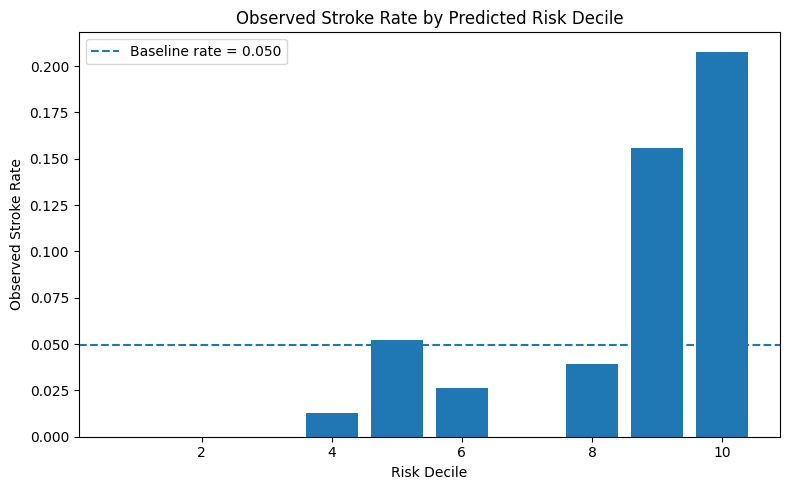

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(lift_df["risk_decile"], lift_df["observed_stroke_rate"])
plt.axhline(baseline_rate, linestyle="--", label=f"Baseline rate = {baseline_rate:.3f}")
plt.xlabel("Risk Decile")
plt.ylabel("Observed Stroke Rate")
plt.title("Observed Stroke Rate by Predicted Risk Decile")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
METADATA_TRIAL_005_DECILE_FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.bar(lift_df["risk_decile"], lift_df["observed_stroke_rate"])
plt.axhline(baseline_rate, linestyle="--", label=f"Baseline rate = {baseline_rate:.3f}")
plt.xlabel("Risk Decile")
plt.ylabel("Observed Stroke Rate")
plt.title("Observed Stroke Rate by Predicted Risk Decile")
plt.legend()
plt.tight_layout()
plt.savefig(METADATA_TRIAL_005_DECILE_FIGURE_PATH)
plt.close()

METADATA_TRIAL_005_DECILE_FIGURE_PATH

WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/reports/figures/experiments/metadata_trial_005_risk_deciles.png')

In [10]:
top_decile = lift_df.sort_values("risk_decile", ascending=False).iloc[0]
bottom_decile = lift_df.sort_values("risk_decile", ascending=True).iloc[0]

report = f"""# Metadata Trial 005 Risk Stratification Evaluation

## Purpose

This experiment evaluates the metadata model as a contextual stroke-risk ranking model rather than an acute stroke classifier.

## Ranking Metrics

- ROC-AUC: {risk_metrics["roc_auc"]:.4f}
- Average precision / PR-AUC: {risk_metrics["average_precision"]:.4f}
- Brier score: {risk_metrics["brier_score"]:.4f}
- Baseline stroke rate: {risk_metrics["baseline_positive_rate"]:.4f}

## Risk Decile Findings

Lowest-risk decile:
- Observed stroke rate: {bottom_decile["observed_stroke_rate"]:.4f}
- Lift: {bottom_decile["lift"]:.2f}x

Highest-risk decile:
- Observed stroke rate: {top_decile["observed_stroke_rate"]:.4f}
- Lift: {top_decile["lift"]:.2f}x

## Interpretation

The metadata model should be interpreted as a background risk stratification model.

It is not designed to diagnose acute stroke. Instead, it ranks patients by contextual risk based on demographic and clinical risk-factor variables.

## Decision

Accepted as a contextual risk-ranking component for fusion with a lower weight than the acute symptom modalities.
"""

METADATA_TRIAL_005_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
METADATA_TRIAL_005_RESULTS_PATH.write_text(report, encoding="utf-8")

print(report)

# Metadata Trial 005 Risk Stratification Evaluation

## Purpose

This experiment evaluates the metadata model as a contextual stroke-risk ranking model rather than an acute stroke classifier.

## Ranking Metrics

- ROC-AUC: 0.8338
- Average precision / PR-AUC: 0.1857
- Brier score: 0.1813
- Baseline stroke rate: 0.0495

## Risk Decile Findings

Lowest-risk decile:
- Observed stroke rate: 0.0000
- Lift: 0.00x

Highest-risk decile:
- Observed stroke rate: 0.2078
- Lift: 4.19x

## Interpretation

The metadata model should be interpreted as a background risk stratification model.

It is not designed to diagnose acute stroke. Instead, it ranks patients by contextual risk based on demographic and clinical risk-factor variables.

## Decision

Accepted as a contextual risk-ranking component for fusion with a lower weight than the acute symptom modalities.

